## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product

---
## Fonction de simulation

In [2]:
def run_simulation(A, omega, E, rho, L, Nx=100, Nt=100, t_end=1):

    v = np.sqrt(E/rho)
    x  = np.linspace(0, L, Nx)
    dx = x[1] - x[0]
    dt = t_end / Nt
    CFL = v * dt / dx
    assert CFL <= 1.0, f"CFL={CFL:.3f} > 1 : schéma instable"

    t_pulse = 2 * np.pi / omega

    def u_right(t):
        if t < t_pulse:
            return A * np.sin(omega * t)
        else:
            return 0.0

    u     = np.zeros(Nx)
    u_dot = np.zeros(Nx)
    u_2   = np.zeros(Nx)

    u_storage         = np.zeros((Nt+1, Nx))
    u_dot_storage     = np.zeros((Nt, Nx))
    u_xx_storage      = np.zeros((Nt, Nx))
    delta_u_storage   = np.zeros((Nt, Nx))

    u_storage[0] = u.copy()

    nodes = np.arange(1, Nx-1)          # nœuds intérieurs (remplace for j in range(1, Nx-1))

    rows = []

    # --- Boucle de simulation ---
    for n in range(Nt):
        tn = n * dt

        u_xx = np.zeros(Nx)
        u_xx[1:-1] = (u[2:] - 2*u[1:-1] + u[:-2]) / dx**2

        u_dot = np.zeros(Nx)
        u_dot[1:-1] = (u[1:-1] - u_2[1:-1]) / dt

        u_new = np.zeros(Nx)
        u_new[1:-1] = (2.0 * u[1:-1] - u_2[1:-1] + CFL**2 * (u[2:] - 2.0 * u[1:-1] + u[:-2]))
        u_new[0]  = 0
        u_new[-1] = u_right(tn)

        u_dot_storage[n]   = u_dot
        u_xx_storage[n]    = u_xx
        #delta_u_storage[n] = u_new - u

        u_2 = u.copy()
        u   = u_new
        u_storage[n+1] = u.copy()

    # --- Construction du dataset (option B : vectorisée sur les nœuds) ---
    for n in range(2, Nt-3):
        rows.append(pd.DataFrame({
            "A":           A,
            "omega":       omega,
            "u_dot@t":     u_dot_storage[n,   nodes],
            "u_dot@t-dt":  u_dot_storage[n-1, nodes],
            "u_dot@t-2dt": u_dot_storage[n-2, nodes],
            "u_xx@t":      u_xx_storage[n,    nodes],
            "u_xx@t-dt":   u_xx_storage[n-1,  nodes],
            "u_xx@t-2dt":  u_xx_storage[n-2,  nodes],


            "delta_u@3dt": u_storage[n+3, nodes] - u_storage[n, nodes],
        }))

    return pd.concat(rows, ignore_index=True)

## Génération du dataset complet

In [3]:
all_dfs = []

#Parameters
E=1
rho=2
L=1

Nt=300
Nx=100
t_end=3

N=6
AMPLITUDES = np.linspace(0.005, 0.1, N).round(3).tolist()
PULSATIONS = np.linspace(7, 90, N).round(1).tolist()

n_sims=len(AMPLITUDES)*len(PULSATIONS)

# We compute each simulation
for idx, (A, w) in enumerate(product(AMPLITUDES, PULSATIONS), start=1):
    df_run = run_simulation(A=A, omega=w, E=E,rho=rho, L=L, Nt=Nt, Nx=Nx, t_end=t_end)
    all_dfs.append(df_run)

# We concatenate each simulation in the df which is the full dataset table
df = pd.concat(all_dfs, ignore_index=True)
print(df.head(0))


Empty DataFrame
Columns: [A, omega, u_dot@t, u_dot@t-dt, u_dot@t-2dt, u_xx@t, u_xx@t-dt, u_xx@t-2dt, delta_u@3dt]
Index: []



## Split train / val / test

In [4]:
rng = np.random.default_rng(seed=42)

combos     = list(product(AMPLITUDES, PULSATIONS))
combos_arr = rng.permutation(combos)

n_train = int(0.70 * n_sims)
n_val   = int(0.15 * n_sims)

train_combos = set(map(tuple, combos_arr[:n_train]))
val_combos   = set(map(tuple, combos_arr[n_train:n_train + n_val]))
test_combos  = set(map(tuple, combos_arr[n_train + n_val:]))

def assign_split(row):
    key = (row["A"], row["omega"])
    if key in train_combos: return "train"
    if key in val_combos:   return "val"
    return "test"

df["split"] = df.apply(assign_split, axis=1)

print("Distribution du split :")
for s in ["train", "val", "test"]:
    n = (df["split"] == s).sum()
    print(f"  {s:5s} : {n:>8,} lignes  ({100*n/len(df):.1f} %)")


Distribution du split :
  train :  722,750 lignes  (69.4 %)
  val   :  144,550 lignes  (13.9 %)
  test  :  173,460 lignes  (16.7 %)


## Normalisation (z-score)

In [5]:
INPUTS = ["u_dot@t","u_dot@t-dt","u_dot@t-2dt","u_xx@t","u_xx@t-dt","u_xx@t-2dt"]
OUTPUTS = ["delta_u@3dt"]


# Masque train pour calculer les stats uniquement sur le train set
train_mask = df["split"] == "train"

# Calcul des stats sur le train set uniquement
norm_stats = pd.DataFrame({
    "mean": df.loc[train_mask, INPUTS + OUTPUTS].mean(),
    "std" : df.loc[train_mask, INPUTS + OUTPUTS].std(),
})
norm_stats["std"] = norm_stats["std"].replace(0, 1)  # éviter division par 0

# Application à tout le dataset
for col in INPUTS + OUTPUTS:
    df[col + "_n"] = (df[col] - norm_stats.loc[col, "mean"]) / norm_stats.loc[col, "std"]

print("Statistiques de normalisation (calculées sur train) :")
print(norm_stats.round(6))

Statistiques de normalisation (calculées sur train) :
                 mean        std
u_dot@t      0.000730   0.583608
u_dot@t-dt   0.000762   0.582574
u_dot@t-2dt  0.000768   0.581582
u_xx@t      -0.009611  86.127885
u_xx@t-dt   -0.006501  85.980803
u_xx@t-2dt  -0.001259  85.832113
delta_u@3dt  0.000017   0.014592


---
## Sauvegarde

In [6]:
COLS_ORDER = (
    INPUTS                                   # inputs bruts
    + [c + "_n" for c in INPUTS]             # inputs normalisés
    + OUTPUTS                                # outputs bruts
    + [c + "_n" for c in OUTPUTS]            # outputs normalisés
    + ["split"]
)
df = df[COLS_ORDER]

# Dataset
df.to_csv("wave_beam_dataset.csv", index=False)
print(f"Dataset sauvegardé : wave_beam_dataset.csv")
print(f"  {len(df):,} lignes × {len(df.columns)} colonnes")

# Stats de normalisation — à recharger dans les fichiers 2 et 3
norm_stats.to_csv("norm_stats.csv")
print(f"Stats de normalisation sauvegardées : norm_stats.csv")

Dataset sauvegardé : wave_beam_dataset.csv
  1,040,760 lignes × 15 colonnes
Stats de normalisation sauvegardées : norm_stats.csv


In [7]:
import json

params_simulation = {
    "L"          : L,
    "Nx"         : Nx,
    "Nt"         : Nt,
    "t_end"      : t_end,
    "E": E,
    "rho":rho,
    "AMPLITUDES" : AMPLITUDES,
    "PULSATIONS" : PULSATIONS,
    "n_sims"     : n_sims,
    "INPUTS":INPUTS,
    "OUTPUTS":OUTPUTS,
}

with open("params_simulation.json", "w") as f:
    json.dump(params_simulation, f, indent=2)

print("Paramètres sauvegardés : params_simulation.json")

Paramètres sauvegardés : params_simulation.json


# 02 — Entraînement du réseau


In [8]:
import numpy as np
import json

with open("params_simulation.json") as f:
    p = json.load(f)

L, Nx, Nt,t_end  = p["L"], p["Nx"], p["Nt"], p["t_end"]
AMPLITUDES    = p["AMPLITUDES"]
PULSATIONS    = p["PULSATIONS"]
n_sims        = p["n_sims"]
E   = p["E"]
rho = p["rho"]
v   = np.sqrt(E / rho)
INPUTS=p["INPUTS"]
OUTPUTS=p["OUTPUTS"]

---
## 1. Paramètres

In [9]:
# Fichiers produits par le notebook 01
DATASET_FILE   = "wave_beam_dataset.csv"
NORMSTATS_FILE = "norm_stats.csv"

# Architecture du réseau
HIDDEN_SIZE = 50    # nombre de neurones par couche cachée
N_LAYERS    = 2     # nombre de couches cachées

# Entraînement
LEARNING_RATE = 1e-3
N_EPOCHS      = 10
BATCH_SIZE    = 512

---
## 2. Chargement des données

In [10]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# Chargement du dataset et des stats de normalisation
df         = pd.read_csv(DATASET_FILE)
norm_stats = pd.read_csv(NORMSTATS_FILE, index_col=0)

#To check and visualise
print(f"Dataset : {len(df):,} lignes")
print(f"Splits  : {df['split'].value_counts().to_dict()}")

# Colonnes normalisées
INPUTS_N = [f"{x}_n" for x in INPUTS]
OUTPUTS_N = [f"{x}_n" for x in OUTPUTS]

# Extraction train / val en utilisant la colonne split du dataset
train_mask = df["split"] == "train"
val_mask   = df["split"] == "val"

X_train = df.loc[train_mask, INPUTS_N].values.astype(np.float32)
y_train = df.loc[train_mask, OUTPUTS_N].values.astype(np.float32)

X_val   = df.loc[val_mask, INPUTS_N].values.astype(np.float32)
y_val   = df.loc[val_mask, OUTPUTS_N].values.astype(np.float32)

print(f"\nTrain : {len(X_train):,} exemples")
print(f"Val   : {len(X_val):,} exemples")

# Conversion en tenseurs PyTorch et création des DataLoaders
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train), torch.tensor(y_train)),
    batch_size=BATCH_SIZE, shuffle=True
)
val_loader = DataLoader(
    TensorDataset(torch.tensor(X_val), torch.tensor(y_val)),
    batch_size=BATCH_SIZE
)

Dataset : 1,040,760 lignes
Splits  : {'train': 722750, 'test': 173460, 'val': 144550}

Train : 722,750 exemples
Val   : 144,550 exemples


---
## 3. Network defintion


In [11]:
class Reseau(nn.Module):

    def __init__(self, n_inputs, n_outputs, hidden_size, n_layers):
        super().__init__()

        couches = []
        taille_entree = n_inputs

        for _ in range(n_layers):
            couches.append(nn.Linear(taille_entree, hidden_size, bias = False))  # couche linéaire
            couches.append(nn.Tanh())                              # activation non-linéaire
            taille_entree = hidden_size

        couches.append(nn.Linear(hidden_size, n_outputs, bias = False))  # couche de sortie

        self.reseau = nn.Sequential(*couches)

    def forward(self, x):
        return self.reseau(x)


modele = Reseau(
    n_inputs    = len(INPUTS_N), 
    n_outputs   = len(OUTPUTS_N),   
    hidden_size = HIDDEN_SIZE,
    n_layers    = N_LAYERS,
)

n_params = sum(p.numel() for p in modele.parameters())
print(modele)
print(f"\nNombre de paramètres : {n_params:,}")

Reseau(
  (reseau): Sequential(
    (0): Linear(in_features=6, out_features=50, bias=False)
    (1): Tanh()
    (2): Linear(in_features=50, out_features=50, bias=False)
    (3): Tanh()
    (4): Linear(in_features=50, out_features=1, bias=False)
  )
)

Nombre de paramètres : 2,850


---
## 4. Training

Epoch    2/10  —  train: 0.0309  |  val: 0.0258  
Epoch    4/10  —  train: 0.0280  |  val: 0.0227  
Epoch    6/10  —  train: 0.0266  |  val: 0.0213  
Epoch    8/10  —  train: 0.0253  |  val: 0.0219  
Epoch   10/10  —  train: 0.0239  |  val: 0.0216  


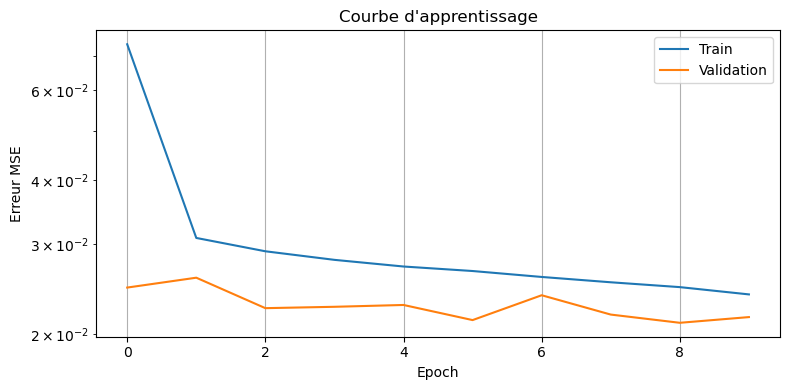

Meilleur modèle rechargé — val minimale : 0.021079


In [12]:
criterion  = nn.MSELoss()   # erreur quadratique moyenne
optimiseur = torch.optim.Adam(modele.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimiseur, mode="min", factor=0.5, patience=10
)

historique_train = []
historique_val   = []

meilleure_val = float("inf")   # on initialise au pire score possible
patience_compteur = 0          # on verra ça après

for epoch in range(1, N_EPOCHS + 1):

    # Phase entraînement
    modele.train()
    perte_train = 0.0       #initialisation of training loss
    for X_batch, y_batch in train_loader:
        
        optimiseur.zero_grad()                       # remet les gradients à zéro

        prediction = modele(X_batch)                 # prédiction

        perte      = criterion(prediction, y_batch)  # erreur

        perte.backward()                             # rétropropagation

        optimiseur.step()                            # mise à jour des poids
        
        perte_train += perte.item()
    perte_train /= len(train_loader)

    # Phase validation : un seul forward pass sur tout le val
    modele.eval()
    with torch.no_grad():
        pred_val = modele(torch.tensor(X_val)).numpy()

    # Loss globale 
    perte_val = ((pred_val - y_val)**2).mean()
    scheduler.step(perte_val)

    # Loss par output
    historique_train.append(perte_train)
    historique_val  .append(perte_val)

    if epoch % 2 == 0:
        print(f"Epoch {epoch:4d}/{N_EPOCHS}  —  "
            f"train: {perte_train:.4f}  |  "
            f"val: {perte_val:.4f}  ")
    
    # Si la val s'est améliorée, on sauvegarde ce modèle
    if perte_val < meilleure_val:
        meilleure_val = perte_val
        torch.save(modele.state_dict(), "model.pth")   # on écrase avec le meilleur

# Courbe d'apprentissage
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(historique_train, label="Train")
ax.plot(historique_val,   label="Validation")
ax.set_xlabel("Epoch") ; ax.set_ylabel("Erreur MSE")
ax.set_title("Courbe d'apprentissage")
ax.set_yscale("log")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

# On recharge le meilleur modèle trouvé pendant l'entraînement
modele.load_state_dict(torch.load("model.pth",weights_only=True ))
print(f"Meilleur modèle rechargé — val minimale : {meilleure_val:.6f}")

---
## Vérification

TypeError: 'Axes' object is not iterable

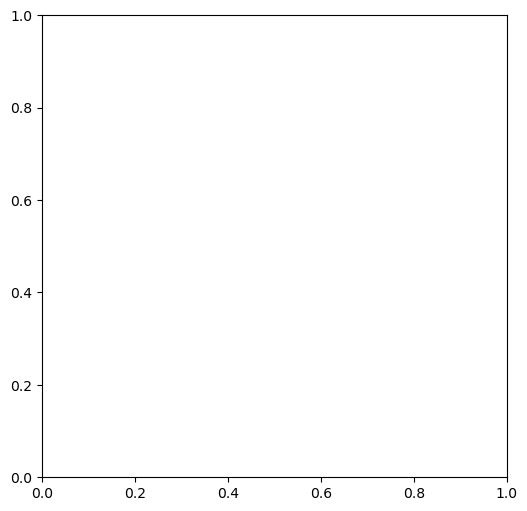

In [13]:
# --- 1. Choisir des paramètres ---
df_test=df[df["split"]=="test"].reset_index(drop=True)

X_new  = df_test[[c + "_n" for c in INPUTS]].values.astype(np.float32)
y_true = df_test[OUTPUTS].values   # shape (N, 3)

# --- 4. Prédiction ---
modele.eval()
with torch.no_grad():
    y_pred_n = modele(torch.tensor(X_new)).numpy()   # shape (N, 3)

# Dénormalisation colonne par colonne
y_pred = np.zeros_like(y_pred_n)
for i, col in enumerate(OUTPUTS):
    mean_du = norm_stats.loc[col, "mean"]
    std_du  = norm_stats.loc[col, "std"]
    y_pred[:, i] = y_pred_n[:, i] * std_du + mean_du

# --- 5. Visualisation : une figure par sortie ---
#fig, axes = plt.subplots(1, len(OUTPUTS), figsize=(6*len(OUTPUTS), 6), squeeze=False)
#axes = axes.flatten()

fig, axes = plt.subplots(1, len(OUTPUTS), figsize=(6*len(OUTPUTS), 6))



for i, (ax, col) in enumerate(zip(axes, OUTPUTS)):
    y_r = y_true[:, i]
    y_p = y_pred[:, i]
    
    ax.scatter(y_r, y_p, alpha=0.4, s=8)
    lim = max(abs(y_r).max(), abs(y_p).max())
    ax.plot([-lim, lim], [-lim, lim], "r--", lw=1, label="prédiction parfaite")
    
    ax.set_xlabel(f"{col} réel")
    ax.set_ylabel(f"{col} prédit")
    
    mse = ((y_p - y_r)**2).mean()
    r2  = 1 - mse / y_r.var()
    ax.set_title(f"{col}\nMSE={mse:.2e}  |  R²={r2:.3f}")
    ax.legend()
    ax.grid(True)

fig.suptitle("Test sur toutes les données test du dataset", fontsize=14)
plt.tight_layout()
plt.show()

# --- 6. Métriques globales ---
for i, col in enumerate(OUTPUTS):
    mse = ((y_pred[:,i] - y_true[:,i])**2).mean()
    r2  = 1 - mse / y_true[:,i].var()
    print(f"{col:15s} : MSE = {mse:.4e}  |  R² = {r2:.4f}")

0.001923
0.017625


/opt/anaconda3/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


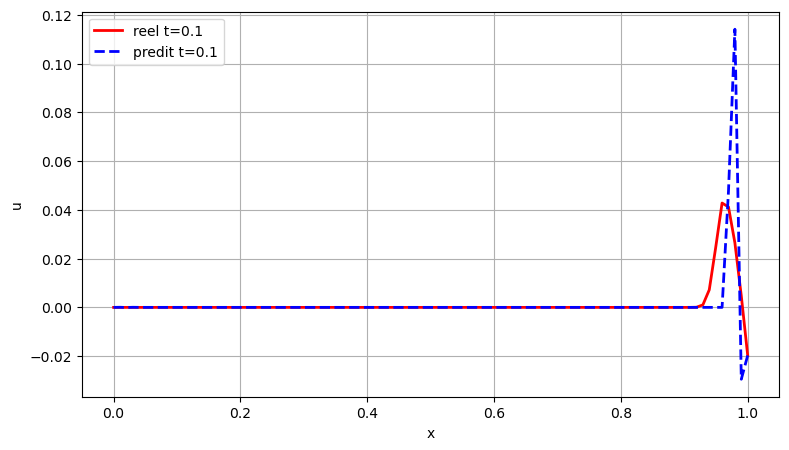

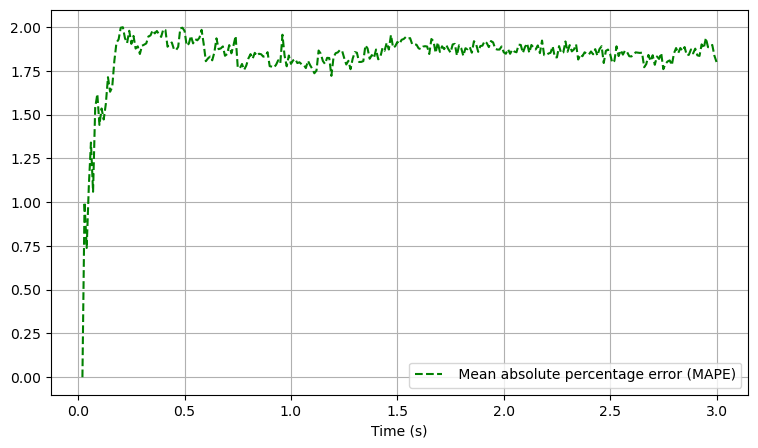

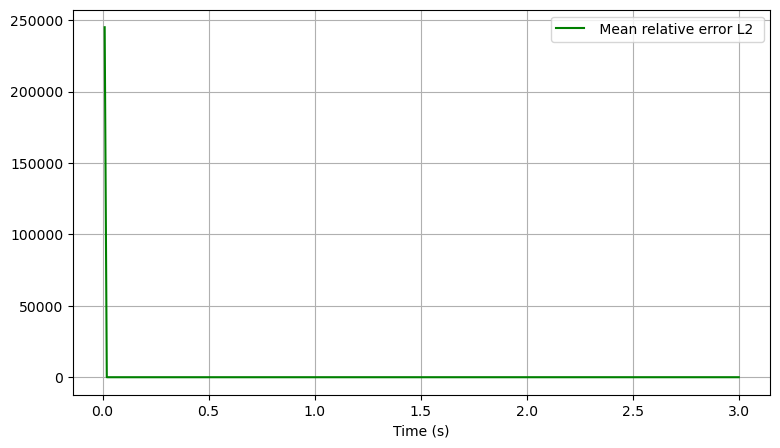

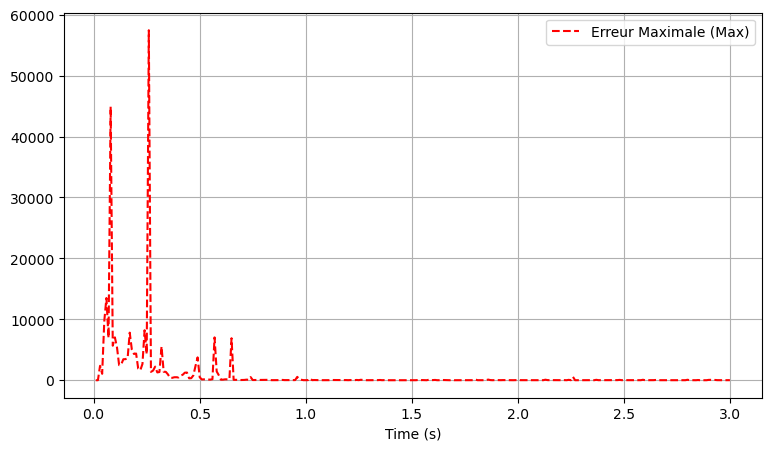

In [ ]:
# Roll out cell  (avance par paquets de 3 pas)


import time

A     = AMPLITUDES[2]
omega = PULSATIONS[2]
dx = L / (Nx - 1)
dt = t_end / Nt
CFL = v * dt / dx                 # mêmes unités que le notebook 1
#t_list = [0.3, 0.6, 0.9]
t_list = [0.1]
x = np.linspace(0, L, Nx)

def past_label(k):
    if k == 0: return "@t"
    if k == 1: return "@t-dt"
    return f"@t-{k}dt"

t_pulse = 2 * np.pi / omega
def u_right(t):
    return A * np.sin(omega * t) if t < t_pulse else 0.0

# stats de normalisation (un mean/std par colonne)
stats_normalisation = {name: {"mean": norm_stats.loc[name, "mean"],
                              "std" : norm_stats.loc[name, "std"]}
                       for name in INPUTS + OUTPUTS}
noms_features = [c[:-2] for c in INPUTS_N]
mu = np.array([stats_normalisation[c]["mean"] for c in OUTPUTS])   # (3,)
sd = np.array([stats_normalisation[c]["std"]  for c in OUTPUTS])   # (3,)

valid = np.arange(1, Nx - 1)

def construire_entree(champs, noeuds):
    e = np.zeros((len(noeuds), len(noms_features)), dtype=np.float32)
    for idx, name in enumerate(noms_features):
        m = stats_normalisation[name]["mean"]
        s = stats_normalisation[name]["std"]
        e[:, idx] = (champs[name][noeuds] - m) / s
    return e

def u_xx_de(uu):
    out = np.zeros(Nx)
    out[1:-1] = (uu[2:] - 2*uu[1:-1] + uu[:-2]) / dx**2
    return out

# =====================================================
# 1) VRAIE simulation (physique)
# =====================================================

start_time_phys = time.perf_counter()

U_reel = np.zeros((Nt + 1, Nx))
u, u_2 = np.zeros(Nx), np.zeros(Nx)
for n in range(Nt):
    u_new = np.zeros(Nx)
    u_new[1:-1] = 2*u[1:-1] - u_2[1:-1] + CFL**2 * (u[2:] - 2*u[1:-1] + u[:-2])
    u_new[0]  = 0.0
    u_new[-1] = u_right(n * dt)
    u_2, u = u.copy(), u_new
    U_reel[n + 1] = u.copy()
reel = {round(k*dt, 5): U_reel[k].copy() for k in range(Nt + 1)}

time_phys = time.perf_counter() - start_time_phys

# =====================================================
# 2) Simulation PREDITE (reseau), par paquets de 3
# =====================================================

start_time_phys = time.perf_counter()

U = np.zeros((Nt + 1, Nx))      # The storage of the displacement u      

# champs_repos = {name: np.zeros(Nx) for name in noms_features}
# with torch.no_grad():
#     sortie_repos = modele(torch.tensor(construire_entree(champs_repos, valid))).numpy()
# bias_repos = (sortie_repos * sd + mu)[0]

# Error initialisation

error_mape=np.zeros(Nt)
error_max=np.zeros(Nt)
error_l2_rel=np.zeros(Nt)

def l2_rel(u_pred, u_reel, eps=1e-12):
    return np.linalg.norm(u_pred - u_reel) / (np.linalg.norm(u_reel) + eps)

def smape (prediction, cible,eps=1e-12):
    mask = cible!= 0
    num=np.abs(cible[mask]-prediction[mask])*2
    den=np.abs(cible[mask]) +np.abs(prediction[mask])
    return np.mean((num/den))

def errormax(cible, prediction,eps=1e-12):
    num = np.abs(cible-prediction)
    den = np.abs(cible)+ eps
    return np.max((num/den))

temps_sim = np.zeros(Nt)

for n in range(0, Nt, 3):

    champs = {}

    for k in range(3):                      
        idx      = max(0, n - k)
        idx_prev = max(0, idx - 1)
        champs[f"u_dot{past_label(k)}"] = (U[idx] - U[idx_prev]) / dt   
        champs[f"u_xx{past_label(k)}"]  = u_xx_de(U[idx])

    with torch.no_grad():
        sortie = modele(torch.tensor(construire_entree(champs, valid))).numpy() 
    #deltas = sortie * sd + mu - bias_repos        
    deltas = sortie * sd + mu                                

    for h in range(3):                     
        if n + h >= Nt:
            break
        u_suiv = U[n + h].copy()
        u_suiv[valid] = U[n][valid] + deltas[:, h]
        u_suiv[0]  = 0.0
        u_suiv[-1] = u_right((n + h) * dt)
        U[n + h + 1] = u_suiv

        # Error computing

        error_mape[n+h] = smape(u_suiv, U_reel[n + h + 1]).mean()

        error_max[n+h] = errormax(u_suiv, U_reel[n + h + 1])
        
        error_l2_rel[n+h] = l2_rel(u_suiv, U_reel[n + h + 1])

        temps_sim[n + h] = round((n + h + 1) * dt, 5)


pred = {round(k*dt, 5): U[k].copy() for k in range(Nt + 1)}

time_pred = time.perf_counter() - start_time_phys

# =====================================================
# 3) Trace
# =====================================================
plt.figure(figsize=(9, 5))
for t, col in zip(t_list, plt.cm.viridis(np.linspace(0, 0.85, len(t_list)))):
    kr = min(reel, key=lambda k: abs(k - t))
    kp = min(pred, key=lambda k: abs(k - t))
    plt.plot(x, reel[kr], color="r", lw=2, label=f"reel t={t}")
    plt.plot(x, pred[kp], color="b", lw=2, ls="--", label=f"predit t={t}")
plt.xlabel("x"); plt.ylabel("u"); plt.legend(); plt.grid(True)

# Time of execution printing

print(round(time_phys,6))
print(round(time_pred,6))

# Plotting errors

plt.figure(figsize=(9, 5))
plt.plot(temps_sim, error_mape, label=" Mean absolute percentage error (MAPE)", color="green", lw=1.5, ls="--")
plt.legend()
plt.grid(True)
plt.xlabel("Time (s)")

plt.figure(figsize=(9, 5))
plt.plot(temps_sim,error_l2_rel, label=" Mean relative error L2 ", color="green", lw=1.5, ls="-")
plt.legend()
plt.grid(True)
plt.xlabel("Time (s)")

plt.figure(figsize=(9, 5))
plt.plot(temps_sim, error_max, label="Erreur Maximale (Max)", color="red", lw=1.5, ls="--")
plt.xlabel("Time (s)")
plt.legend()
plt.grid(True)

plt.show()